# PHZ 3152 Homework Assignment #2 (10 pts + 2 extra pts)

### Due: 11:59 pm on Monday, September 28


## Instruction: 
Do all homework in this Jupyter notebook and submit your final .ipynb file via Canvas. Show ALL your work and try to add comment lines as needed to describe what your code does. 

You are encouraged to discuss homework problems with your classmates. However, your python script and answers to the questions must be written by yourself.

It's a common sense but just to make sure, when you make a figure make sure they are readable/understandable. If you cannot see the title, labels, data points, or if you don't understand the point of the figure, I won't probably be able to see/understand them either.


## Here are some routines from the class notebook for you to use

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def trapezoid(func, a, b, N):
    '''Trapezoid rule with N slices.'''
    h = (b - a)/N
    x = a + h*np.arange(N + 1)
    y = func(x)
    return h*(0.5*y[0] + 0.5*y[-1] + np.sum(y[1:-1]))

def simpson(func, a, b, N):
    '''Simpson's rule with N slices. N must be even.'''
    if N % 2 != 0:
        raise ValueError(f"Simpson's rule needs an even N, got {N}")
    h = (b - a)/N
    x = a + h*np.arange(N + 1)
    y = func(x)
    return (h/3.0)*(y[0] + y[-1] + 4.0*np.sum(y[1:-1:2]) + 2.0*np.sum(y[2:-1:2]))

def bisection(func, a, b, tol=1e-12, maxiter=200):
    '''Bisection. Returns (root, number_of_iterations).'''
    fa, fb = func(a), func(b)
    if fa*fb > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")
    n = 0
    while b - a > tol and n < maxiter:
        m = 0.5*(a + b)
        fm = func(m)
        if fm == 0.0:
            return m, n
        if fa*fm < 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
        n += 1
    return 0.5*(a + b), n

---
## Problem 1 — A Cup of Coffee Cooling Down (7 pts)

A fresh cup of coffee starts at $T_0 = 90\;^\circ$C in a room at $T_{\rm room} = 22\;^\circ$C. Newton's law of cooling says the coffee loses heat at a rate proportional to how much hotter it is than the room, which gives

$$
T(t) = T_{\rm room} + (T_0 - T_{\rm room})\,e^{-t/\tau},
$$

with $t$ in minutes. For this mug the cooling time is $\tau = 12$ min.

(a) (1 pt) Write a function `T_coffee(t)` that computes the temperature of the coffee at time $t$, and plot it from $t = 0$ to $60$ min with a dashed horizontal line at room temperature. From the plot, appoximately (i.e., by eye) when does the coffee pass $60\;^\circ$C?

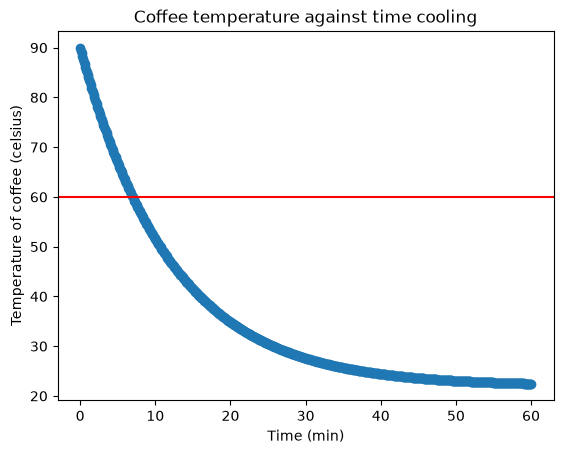

Approximately at 9 minutes is when the coffee passes 60 degrees celsius.


In [2]:
def T_coffee(t):
    t_room=22
    t_0=90
    tau=12

    return t_room+(t_0-t_room)*np.exp(-t/tau)


time_x=np.linspace(0,60,600)
temp_y=T_coffee(time_x)
plt.plot(time_x, temp_y, 'o-')
plt.axhline(60, color='red')
plt.xlabel("Time (min)")
plt.ylabel("Temperature of coffee (celsius)")
plt.title("Coffee temperature against time cooling")
plt.show()

print("Approximately at 9 minutes is when the coffee passes 60 degrees celsius.")

Now, let's find the time at which the coffee is exactly $60\;^\circ$C by solving $T(t) - 60 = 0$, using **three** methods we covered in class:



(b) (1 pt) Use the `bisection` routine. Remember that you need to start with a good initial range. Report the root and the number of iterations, and check your numerical answer against the exact answer $t = \tau\ln\!\big[(T_0-T_{\rm room})/(60-T_{\rm room})\big]$. 




In [3]:
tau=12
t_0=90
t_room=22
exact_ans=tau*np.log((t_0-t_room)/(60-t_room))

def T_coffee_at_60(t):
    '''T(t)-60 function'''
    t_room=22
    t_0=90
    tau=12

    return t_room+(t_0-t_room)*np.exp(-t/tau)-60
    
a=5
b=10
root, num_iter=bisection(T_coffee_at_60, a, b) 

print("Approximated root: ", root, "\nExact answer: ", exact_ans)
print("Number of iterations: ", num_iter)





Approximated root:  6.9830585453965455 
Exact answer:  6.983058545396652
Number of iterations:  43


(c) (1 pt) Repeat (b) but using the `Newton–Raphson` method. Remember that you need to define the derivative of $T(t)$ as a function. 



In [4]:
from scipy.optimize import newton

def T_coffee_at_60_prime(t):
    '''The first derivative of T_coffee_at_60 function'''
    t_room=22
    t_0=90
    tau=12

    return (-1/tau)*(t_0-t_room)*np.exp(-t/tau)

x_0=5
root, full_report=newton(T_coffee_at_60, x_0, 
                         T_coffee_at_60_prime,
                         full_output=True)

print("Approximated root: ", root)
print("Exact answer: ", exact_ans)
print("Number of iterations: ", full_report['iterations'])

Approximated root:  6.983058545396651
Exact answer:  6.983058545396652
Number of iterations:  4


(d) (1 pt) Repeat (b) but using `scipy.optimize.brentq`. 


In [5]:
from scipy.optimize import brentq

a=5
b=10
root, full_report=brentq(T_coffee_at_60, a, b, full_output=True)

print("Approximated root: ", root)
print("Exact answer: ", exact_ans)
print("Number of iterations: ", full_report['iterations'])

Approximated root:  6.983058545396669
Exact answer:  6.983058545396652
Number of iterations:  7


(e) (1 pt) What is the **average temperature** of the coffee over the first 30 minutes, which can be computed using

$$
\bar T = \frac{1}{30}\int_0^{30} T(t)\,dt \;?
$$

Compute this integral with the trapezoid rule and with Simpson's rule for $N = 4, 8, 16, 32$ slices. For each $N$ value used, print out the error against the exact value, which you can get by integrating the formula by hand:

$$
\int_0^{30} T\,dt = 30\,T_{\rm room} + (T_0 - T_{\rm room})\,\tau\left(1 - e^{-30/\tau}\right).
$$


In [6]:
t_room=22
t_0=90
tau=12

exact_avg=30*t_room + (t_0-t_room)*tau*(1-np.exp(-30/tau))

a=0
b=30
trap_errors=[]
simp_errors=[]
for n in [4,8,16,32]:
    trap_error=np.abs(trapezoid(T_coffee, a, b, n) - exact_avg) 
    simp_error=np.abs(simpson(T_coffee, a, b, n) - exact_avg)
    
    print(f"N={n}:   Trapezoid abs error: {trap_error:.3e}, Simpson abs error: {simp_error:.3e}")

    trap_errors.append(trap_error)
    simp_errors.append(simp_error)



N=4:   Trapezoid abs error: 2.422e+01, Simpson abs error: 6.066e-01
N=8:   Trapezoid abs error: 6.086e+00, Simpson abs error: 3.923e-02
N=16:   Trapezoid abs error: 1.523e+00, Simpson abs error: 2.473e-03
N=32:   Trapezoid abs error: 3.809e-01, Simpson abs error: 1.549e-04


(f) (1 pt) From (e), make a plot showing the error as a function of slice size and fit the error to compute the order of accuracy of each rule.

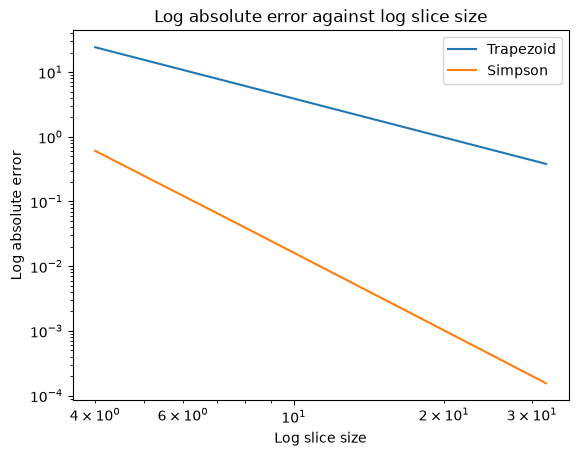

Order of accuracy for trapezoid: 1.997067391803967
Order of accuracy for simpson: 3.979285233345184


In [7]:
step_x=[4,8,16,32]

plt.loglog(step_x, trap_errors, label="Trapezoid")
plt.loglog(step_x, simp_errors, label="Simpson")
plt.legend()
plt.xlabel("Log slice size")
plt.ylabel("Log absolute error")
plt.title("Log absolute error against log slice size")
plt.show()


slope, _ = np.polyfit(np.log10(step_x), np.log10(trap_errors), 1)
print("Order of accuracy for trapezoid:", -slope) #expected is 2

slope, _ = np.polyfit(np.log10(step_x), np.log10(simp_errors), 1)
print("Order of accuracy for simpson:", -slope) #expected is 2

(g) (1 pt) In the laboratory, you do not have a formula but you have a thermometer. Here are seven measurements of the same cup, taken every 5 minutes and recorded to the nearest $0.1\;^\circ$C:

| $t$ (min) | 0 | 5 | 10 | 15 | 20 | 25 | 30 |
|---|---|---|---|---|---|---|---|
| $T$ ($^\circ$C) | 90.0 | 66.8 | 51.6 | 41.5 | 34.8 | 30.5 | 27.6 |

Apply Trapezoid rule to these numbers to get the average temperature using 

$$
\bar T = \frac{1}{30}\int_0^{30} T(t)\,dt \;
$$
 and compare with the exact value from part (e).

In [8]:
temps=[90,66.8,51.6,41.5,34.8,30.5,27.6]
times=[5*x for x in range(7)]

approx_avg=0
step_size=5
for i in range(len(temps)-1):
    #trap method
    approx_avg+=0.5*step_size*(temps[i]+temps[i+1])

exact_avg=30*t_room + (t_0-t_room)*tau*(1-np.exp(-30/tau))

print("Approximated avg: ", approx_avg)
print("Exact avg: ", exact_avg)
print("The approximated value is suprisingly pretty close to the exact average.")


Approximated avg:  1420.0
Exact avg:  1409.0186411228985
The approximated value is suprisingly pretty close to the exact average.


---
## Problem 2 — Lifting a Satellite (3 pts)

To raise a mass $m$ from the surface of the Earth you have to work against gravity, which weakens with height:

$$
F(r) = \frac{GM m}{r^2}.
\qquad
$$

The work done by gravity is 
$$
W(h) = \int_{R_{\rm Earth}}^{R_{\rm Earth}+h} F(r)\,dr ,
$$

where $r$ is measured from the centre of the Earth. 

The above integral has a closed form, $W(h) = GMm\left(\dfrac{1}{R_{\rm Earth}} - \dfrac{1}{R_{\rm Earth}+h}\right)$, which we will use only to check the numerics.

Throughout this problem, use the following constants as needed.

$$
GM = 3.986\times10^{14}\ \mathrm{m^3/s^2}
\qquad
R_{\rm Earth} = 6.371\times10^{6}\ \mathrm{m}
\qquad
m = 450000\ \mathrm{kg}
$$


(a) (1 pt) The International Space Station orbits at about $h = 400$ km (don't forget that you should convert this unit to meters!). Write the function `F_grav(r)` and compute $W(400\ \mathrm{km})$ with Simpson's rule for $N = 2, 4, 8, 16$ slices.

In [9]:
GM=3.986e14
R_earth=6.371e6
m=45e4
h=4e5

def F_grav(r):
    global GM
    global m
    return GM*m/(r**2)

for i in [2,4,8,16]:
    simp_approx=simpson(F_grav, R_earth, R_earth+h, N=i)
    print(f"At {i} slices, W(400km)={simp_approx:.8e} Joules")

expected_val=GM*m*(1/R_earth-1/(R_earth+h))
print()
print(f"Expected value: {expected_val:.8e} Joules") 

At 2 slices, W(400km)=1.66321973e+12 Joules
At 4 slices, W(400km)=1.66321884e+12 Joules
At 8 slices, W(400km)=1.66321879e+12 Joules
At 16 slices, W(400km)=1.66321878e+12 Joules

Expected value: 1.66321878e+12 Joules


Now let the mass go all the way to $h \to \infty$:

$$
W_\infty = \int_{R_{\rm Earth}}^\infty \frac{GMm}{r^2}\,dr.
$$

Of course, here we considered the gravity of Earth only and ignored the gravity of the Sun. In reality, we should also consider Sun's gravity (and the Milky Way's gravity, etc. if we really want to send it to infinity).


This is an **improper integral**  so let's try the two strategies from class. Note that this integral has an analytic solution, which is 

$$
W_\infty =  \frac{GMm}{R_{\rm Earth}}.
$$

(b) (1 pt) *Truncate.* Instead of integrating all the way to $\infty$, integrate from $R_{\rm Earth}$ to $X \times R_{\rm Earth}$ with Simpson. First, make a plot showing $W_\infty$ for a range of $X$ values and determine what is a good $X$ value to use. For this work, let's use 100 slices in Simpson's rule. What is the total work needed from your Simpson integration and how does that compare with the analytic solution?

100%|███████████████████████████████████████| 49/49 [00:00<00:00, 24996.46it/s]


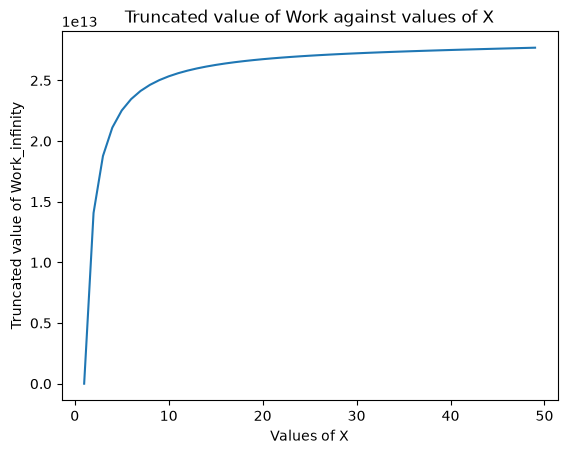

Expected value: 2.815e+13
A good x value is around 50.
The total work needed from the Simpson integration is 2.7699e+13, which is very close in value to the analytical solution.


In [10]:
from tqdm import tqdm 

X=list(range(1,50))
simp_approxs=[]

for i in tqdm(X):
    trunc_approx=simpson(F_grav, R_earth, i*R_earth, N=100)
    simp_approxs.append(trunc_approx)

plt.plot(X, simp_approxs)
plt.xlabel("Values of X")
plt.ylabel("Truncated value of Work_infinity")
plt.title("Truncated value of Work against values of X")
plt.show()

expected_val=GM*m/R_earth

print(f"Expected value: {expected_val:.3e}")
print("A good x value is around 50.")
print(f"The total work needed from the Simpson integration is {simp_approxs[-1]:.4e}, which is very close in value to the analytical solution.")


(c) (1 pt) *Transform.* Substitute $u = R/r$, so that $r = R/u$ and $dr = -\dfrac{R}{u^2}du$. Show on the following markdown cell that the integral becomes

$$
W_\infty = \int_0^1 \frac{GMm}{R}\,du ,
$$

then evaluate this function with Simpson. What is the total work needed from your Simpson integration and how does that compare with the analytic solution?

### work
Substituting $r=\frac{R}{u}$ and $dr=\frac{-R}{u^2}du$ into the integral results as the following:
\begin{align*}
    W_\infty &= \int_1^0 GMm\times \frac{u^2}{R^2}\times\frac{-R}{u^2}du \\
             &= \int_1^0 \frac{-GMm}{R}du \\
             &= \int_0^1 \frac{GMm}{R}du
\end{align*}

In [11]:
def sub_F_grav(r):
    global GM
    global m
    global R_earth
    return GM*m/R_earth+(r-r)

a=0
b=1
transf_approx=simpson(sub_F_grav, a, b, N=10) 
expected_val=GM*m/R_earth

print(f"Expected value: {expected_val:.3e}")
print(f"Transformed approximation is {transf_approx:.4e}.")
print("The approximation is equal to the expected value.")



Expected value: 2.815e+13
Transformed approximation is 2.8154e+13.
The approximation is equal to the expected value.


---
## Extra Credit (2 pts) — How Much Fuel Does That Take?

Parts (b) and (c) gave the energy needed to send a $450{,}000$ kg payload infinitely far away. Liquid methane releases

$$
\varepsilon = 5.55\ \times 10^7\ \mathrm{J/kg}
$$

when it is burned, so it is tempting to divide one number by the other and be done.

That answer is **wrong**, and the reason is what this problem is about: *the fuel has to be lifted too.* A kilogram of methane sitting in the tank at launch is itself hauled part of the way up before it is burned, and hauling it costs energy. So the mass appearing in $F = GMm/r^2$ is no longer the constant $450{,}000$ kg. It is

$$
m(r) = m_{\rm payload} + m_{\rm fuel}(r),
$$

where $m_{\rm fuel}(r)$ is the fuel still unburned when the rocket has reached radius $r$. It starts at whatever we loaded on the pad and falls to zero as $r \to \infty$.

(d) (1 pt) Consider climbing one thin shell, from $r$ to $r + dr$. Crossing it, the rocket burns a mass $|dm|$ of methane and releases $\varepsilon\,|dm|$ of energy, and all of that energy goes into the gravitational work $\dfrac{GM\,m(r)}{r^2}\,dr$ done on the **current** total mass.

Write down that energy balance, show that it separates into

$$
\frac{dm}{m} = -\frac{GM}{\varepsilon}\,\frac{dr}{r^2},
$$

and integrate from the surface out to infinity to show that

$$
\ln\!\left(\frac{m_0}{m_{\rm payload}}\right)
= \frac{1}{\varepsilon}\int_{R_{\rm Earth}}^{\infty}\frac{GM}{r^{2}}\,dr
\;\equiv\; \frac{J}{\varepsilon},
$$

where $m_0$ is the total mass on the pad and $J$ is the **specific** escape energy (energy per kilogram).

Evaluate $J$ numerically with Simpson's rule, using the same $u = R/r$ substitution that worked so well in part (c), and report the fuel mass needed on the pad,

$$
m_{\rm fuel,0} = m_0 - m_{\rm payload},
$$

in kilograms.

### work
Since energy cannot be destroyed nor created, the sum of energy at any single instance must be equal to 0.
That is, $\epsilon|dm| + \frac{GMm}{r^2}dr=0$. Assuming that $dm>0$, we can get rid of the absolute value signs to get the following:
\begin{align*}
    & \epsilon dm + \frac{GMm}{r^2}dr=0 \\
    & \epsilon dm = -\frac{GMm}{r^2}dr \\
    & \frac{dm}{m} = -\frac{GM}{\epsilon}\frac{dr}{r^2}
\end{align*}

We now integrate both sides from the surface out to infinity. Let $m_p$ and $m_f$ denote $m_{payload}$ and $m_{fuel}$, respectively. At the surface level, we see that $m(r)=m_{p}+m_{f}$, and as $r\rightarrow\infty$, it follows that $m(r)=m_{p}$. Taking this into account, we get:
\begin{align*}
     \int_{m_{p}+m_{f}}^{m_{p}} \frac{1}{m} dm &= -\frac{1}{\epsilon}\int_{R_{Earth}}^\infty \frac{GM}{r^2}dr \\
     \left[ \ln |m| \right]_{m_{p}+m_{f}}^{m_{p}} &= -\frac{1}{\epsilon}\int_{R_{Earth}}^\infty \frac{GM}{r^2}dr \\
     \ln \frac{|m_p|}{|m_p+m_f|} &= -\frac{1}{\epsilon}\int_{R_{Earth}}^\infty \frac{GM}{r^2}dr \\
     \ln \frac{|m_p+m_f|}{|m_p|} &= \frac{1}{\epsilon}\int_{R_{Earth}}^\infty \frac{GM}{r^2}dr \\
\end{align*}

Setting $m_0=m_p+m_f$ and assuming that $m_p,m_f>0$, we rewrite the last equation as follow:
$$     \ln \left( \frac{m_0}{m_p} \right)  = \frac{1}{\epsilon}\int_{R_{Earth}}^\infty \frac{GM}{r^2}dr
$$


Since $\ln(\frac{m_0}{m_p})=\frac{J}{\epsilon}$, it follows that $m_0=e^{\frac{J}{\epsilon}}m_p$ and as a result, $m_f=m_0-m_p=m_p( e^{\frac{J}{\epsilon}} - 1)$.


In [17]:
def sub_F_grav_sj(r):
    global GM
    global R_earth
    return GM/R_earth+(r-r)
    
J=simpson(sub_F_grav_sj, a, b, N=10)

epsilon=5.55e7
print(J)

fuel_needed=m*np.exp(np.float128(J/epsilon)-1)
print(f"The fuel needed is {fuel_needed:.4e}.")

62564746.507612616
The fuel needed is 5.1109e+05.


(e) (1 pt) Make a plot showing the total mass $m(r)$ against $r/R_{\rm Earth}$. **Compute** at what radius 90% of the fuel has been burned. Comment on your answer.